# Teleportazione quantistica nel paradigma MBQC 
su cluster lineare a quattro qubit

## References
- _A One-Way Quantum Computer_, Raussendorf R. and Briegel H.J., Phys. Rev. Lett., 86, 22, 5188--5191, 2001, American Physical Society, [url](https://link.aps.org/doi/10.1103/PhysRevLett.86.5188)


## Setup dell'ambiente

Le celle seguenti installano le dipendenze e impostano come directory di lavoro
la cartella che contiene il notebook. Dopo l'installazione delle dipendenze può
essere necessario riavviare il kernel.

Su Google Colab, il setup scarica il repository (branch `main`) e seleziona la cartella dell’esempio prima di installare le dipendenze. Se richiesto, riavvia la sessione e riesegui le celle. Il clone viene riutilizzato nella stessa sessione; per scaricare aggiornamenti da GitHub, avvia una nuova sessione Colab.


In [ ]:
from pathlib import Path
import os
import subprocess

try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    repository = Path("/content/mbqc-codes")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/AlbertoMiserendino/mbqc-codes.git",
            str(repository),
        ], check=True)
    os.chdir(repository / "01-mbqc-teleport")

%pip install -r "../requirements.txt" -q
# If prompted, restart the runtime/kernel and run the cells again.


In [2]:
from pathlib import Path
import os
import ipynbname

# Automated runs already start in the notebook directory.
if not Path("mbqc-teleport-v1a.qasm").is_file():
    os.chdir(ipynbname.path().parent)


/home/alberto/qc/01-mbqc-teleport


## Circuiti MBQC per la teleportazione

Consideriamo un cluster lineare di quattro qubit

$$
q_0 - q_1 - q_2 - q_3,
$$

dove $q_0$ contiene lo stato arbitrario da teleportare,

$$
|\psi\rangle =
R_z(\phi)R_y(\theta)|0\rangle
\sim
\cos\frac{\theta}{2}|0\rangle
+ e^{i\phi}\sin\frac{\theta}{2}|1\rangle,
$$

mentre $q_1,q_2,q_3$ vengono inizializzati in $|+\rangle$.
I collegamenti del cluster sono realizzati mediante porte $CZ$.

Le due celle successive caricano e visualizzano due varianti OpenQASM del circuito.


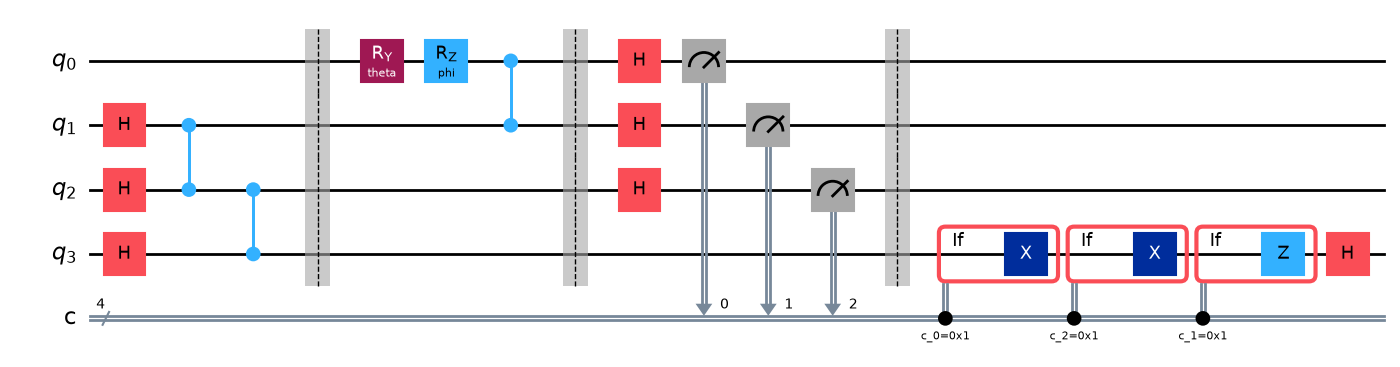

In [3]:
from qiskit import qasm3

qc = qasm3.load(
    "mbqc-teleport-v1a.qasm"
    )

qc.draw("mpl")

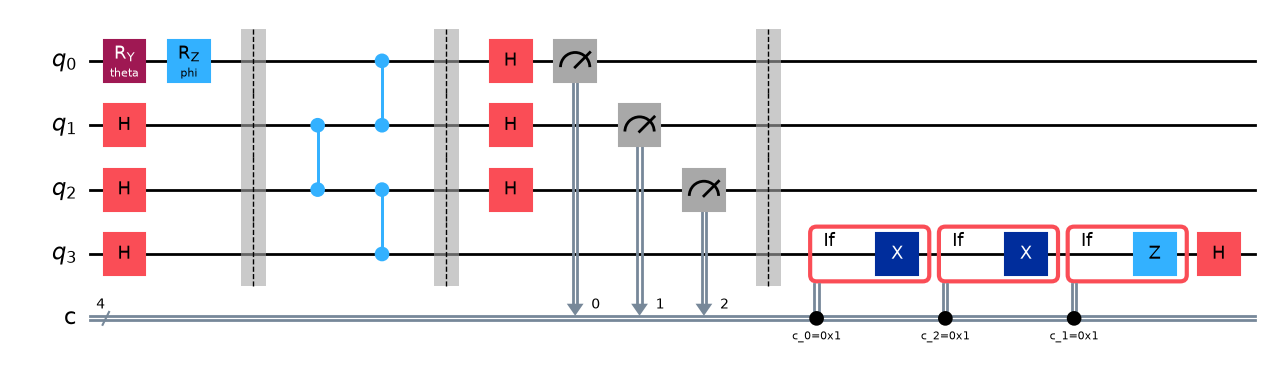

In [4]:
from qiskit import qasm3

qc = qasm3.load(
    "mbqc-teleport-v1b.qasm"
    )

qc.draw("mpl")

in questa configurazione, preparare un qubit nello stato desiderato, quindi intrecciarlo insieme a $\left|+\right\rangle^{\otimes N}$, usando $S$ è analogo a creare $S\left|+\right\rangle^{\otimes N}$ e intrecciarlo con un $CZ$. Cambia solo la definizione dell'operatore $S$.

## Feed-forward e correzioni di Pauli

Ogni passo elementare di teleportazione lungo il cluster produce

$$
|\psi\rangle \longrightarrow X^{m}H|\psi\rangle,
$$

dove $m\in\{0,1\}$ è il risultato della misura nella base $X$.

Con tre misure consecutive si ottiene

$$
|\psi_{\mathrm{out}}\rangle
=
X^{m_2}H\,X^{m_1}H\,X^{m_0}H|\psi\rangle.
$$

Gli operatori $X$ e $H$ **non commutano**. Si usano invece le identità

$$
HX^m = Z^mH,
\qquad
HZ^m = X^mH.
$$

Passo per passo:

$$
X^{m_1}H X^{m_0}H|\psi\rangle
=
X^{m_1}Z^{m_0}|\psi\rangle,
$$

e quindi

$$
X^{m_2}H X^{m_1}Z^{m_0}|\psi\rangle
=
X^{m_2}Z^{m_1}X^{m_0}H|\psi\rangle.
$$

A meno di una fase globale,

$$
\boxed{
|\psi_{\mathrm{out}}\rangle
=
X^{m_0\oplus m_2} Z^{m_1} H|\psi\rangle
}.
$$

Il feed-forward deve quindi applicare $X^{m_0\oplus m_2}$, $Z^{m_1}$
e infine $H$ per recuperare $|\psi\rangle$ (l'$H$ finale serve solo se il numero di teleportazioni è dispari, qui sono 3).

L'operatore $X^{m_0\oplus m_2}$ può essere implementato senza calcolare
esplicitamente lo XOR:

$$
X^{m_0}X^{m_2}=X^{m_0\oplus m_2},
$$

poiché $X^2=I$. In OpenQASM è quindi sufficiente applicare una $X$
condizionata a $m_0$ e una seconda $X$ condizionata a $m_2$.


## Parametri dello stato di ingresso

Gli angoli $\theta$ e $\phi$ determinano il punto sulla sfera di Bloch.
In questa sezione si individuano i parametri simbolici del circuito e si assegnano
valori numerici per poter eseguire la simulazione.

Per lo stato

$$
|\psi\rangle =
\cos\frac{\theta}{2}|0\rangle
+ e^{i\phi}\sin\frac{\theta}{2}|1\rangle,
$$

il vettore di Bloch teorico è

$$
\mathbf r =
\left(
\sin\theta\cos\phi,\;
\sin\theta\sin\phi,\;
\cos\theta
\right).
$$


In [5]:
print(qc.num_parameters)
print(qc.parameters)

2
ParameterView([Parameter(phi), Parameter(theta)])


In [6]:
params = {p.name: p for p in qc.parameters}

import numpy as np
theta_value = np.pi / 2
phi_value = np.pi / 4

import numpy as np
qc_bound = qc.assign_parameters({
    params["theta"]: theta_value,
    params["phi"]: phi_value
})

In [7]:
print(qc_bound.parameters)

ParameterView([])


## Verifica dello stato teleportato

Dopo la teleportazione, il qubit di uscita è $q_3$. Per verificare che esso
contenga lo stato iniziale si stimano le tre componenti del vettore di Bloch,
cioè $\langle X\rangle$, $\langle Y\rangle$ e $\langle Z\rangle$.

Una misura nella base $Z$ è diretta. Per misurare nelle altre basi si effettua
prima un cambio di base:

$$
M_X = M_Z H,
\qquad
M_Y = M_Z H S^\dagger.
$$

Per questo vengono create tre copie del circuito, una per ciascuna base di misura.


In [8]:
qc_z = qc_bound.copy()
qc_z.measure(3, 3)

qc_x = qc_bound.copy()
qc_x.h(3)
qc_x.measure(3, 3)

qc_y = qc_bound.copy()
qc_y.sdg(3)
qc_y.h(3)
qc_y.measure(3, 3)

## Simulazione

Il circuito viene eseguito molte volte (\emph{shots}) con `AerSimulator`.
I conteggi ottenuti nelle basi $X$, $Y$ e $Z$ permettono di ricostruire
sperimentalmente il vettore di Bloch del qubit $q_3$.


In [9]:
from qiskit_aer import AerSimulator
sim = AerSimulator()

shots = 10000

result_x = sim.run(qc_x, shots=shots).result()
result_y = sim.run(qc_y, shots=shots).result()
result_z = sim.run(qc_z, shots=shots).result()

counts_x = result_x.get_counts()
counts_y = result_y.get_counts()
counts_z = result_z.get_counts()

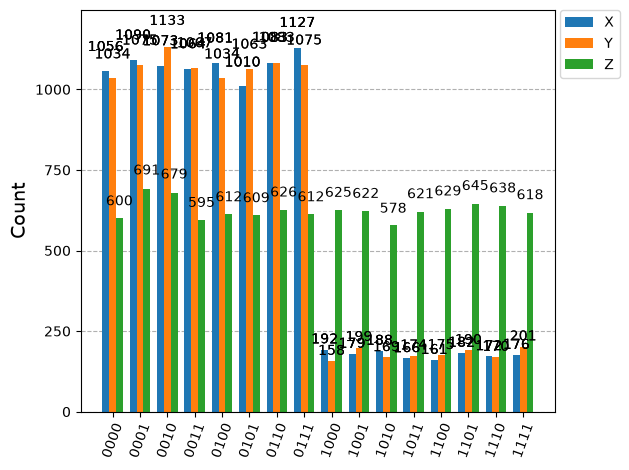

In [10]:
from qiskit.visualization import plot_histogram
from IPython.display import display

display(plot_histogram([counts_x, counts_y, counts_z],
                       legend=["X", "Y", "Z"]))

## Marginalizzazione sul solo qubit di uscita

Il circuito contiene anche i bit classici provenienti dalle misure MBQC.
Per la verifica finale interessa però soltanto il risultato della misura di $q_3$.

Si estraggono quindi i conteggi marginali relativi al bit classico associato
al qubit di uscita.


In [11]:
from qiskit.result import marginal_counts
mx = marginal_counts(counts_x, indices=[3])
my = marginal_counts(counts_y, indices=[3])
mz = marginal_counts(counts_z, indices=[3])

print("X:", mx)
print("Y:", my)
print("Z:", mz)

X: {'1': 1416, '0': 8584}
Y: {'1': 1436, '0': 8564}
Z: {'0': 5024, '1': 4976}


## Valori di aspettazione

Per una misura di Pauli $P\in\{X,Y,Z\}$, con risultati codificati come
$0$ e $1$, il valore di aspettazione si stima come

$$
\langle P\rangle =
\frac{N_0-N_1}{N_0+N_1}.
$$

Le tre quantità ottenute costituiscono il vettore di Bloch misurato

$$
\mathbf r_{\mathrm{meas}}
=
\bigl(
\langle X\rangle,
\langle Y\rangle,
\langle Z\rangle
\bigr).
$$


In [12]:
def expectation(counts):
    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)

    return (n0 - n1) / (n0 + n1)


x_meas = expectation(mx)
y_meas = expectation(my)
z_meas = expectation(mz)

print("<X> =", x_meas)
print("<Y> =", y_meas)
print("<Z> =", z_meas)

<X> = 0.7168
<Y> = 0.7128
<Z> = 0.0048


## Confronto con il risultato teorico

Per lo stato preparato mediante $R_y(\theta)$ seguito da $R_z(\phi)$,
i valori teorici sono

$$
\langle X\rangle = \sin\theta\cos\phi,
\qquad
\langle Y\rangle = \sin\theta\sin\phi,
\qquad
\langle Z\rangle = \cos\theta.
$$

Se la teleportazione e il feed-forward sono corretti, questi valori devono
coincidere, entro l'errore statistico, con quelli ricavati dalla simulazione.


In [13]:
x_theory = np.sin(theta_value) * np.cos(phi_value)
y_theory = np.sin(theta_value) * np.sin(phi_value)
z_theory = np.cos(theta_value)

print("Teorico:")
print("<X> =", x_theory)
print("<Y> =", y_theory)
print("<Z> =", z_theory)

Teorico:
<X> = 0.7071067811865476
<Y> = 0.7071067811865475
<Z> = 6.123233995736766e-17


## Fedeltà

Per uno stato target puro con vettore di Bloch $\mathbf r_{\mathrm{th}}$ e
uno stato ricostruito con vettore $\mathbf r_{\mathrm{meas}}$, la fedeltà è

$$
F =
\frac{1+\mathbf r_{\mathrm{th}}\cdot\mathbf r_{\mathrm{meas}}}{2}.
$$

A causa delle fluttuazioni statistiche dovute al numero finito di shots, la norma
del vettore ricostruito può risultare leggermente maggiore di $1$; la cella
seguente lo riporta allora sulla sfera di Bloch prima di calcolare la fedeltà.


In [14]:
r_meas = np.array([x_meas, y_meas, z_meas])
norm = np.linalg.norm(r_meas)
if norm > 1:
    r_meas = r_meas / norm

In [15]:
r_theory = np.array([
    x_theory,
    y_theory,
    z_theory
])

fidelity = (1 + np.dot(r_theory, r_meas)) / 2

In [16]:
print("Fidelity =", fidelity)

Fidelity = 0.9999924063120922
